# Doğal Dil İşleme + Karar Bilimi (Natural Language Processing + Decision Science)

👩🏻‍🏫 Bu görevde şunları bir araya getireceğiz:
* 🗣 Doğal Dil İşleme (Natural Language Processing)
* 📊 Karar Bilimi (Decision Science)

🎯 Amaç, Olist üzerindeki ürünlerin ve satıcıların **olumsuz (kötü) yorumlarını** anlamaktır.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Data Manipulation
import numpy as np
import pandas as pd
pd.set_option("display.max_columns",None)

# Machine Learning
from sklearn.pipeline import make_pipeline

# Language Processing
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
import string
import unidecode as unidecode

# Vectorizers and NLP Models
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

🕵🏻‍♂️ Olist’in CEO’su [Tiago Dalvi](https://www.linkedin.com/in/tiagodalvi/)’nin senden yorumları okuyup anlamanı istediğini hayal et.

- Müşteriler siparişlerini **1**, **2** veya **3** puanla değerlendirdiklerinde ne söylediler?
- En sık karşılaşılan olumsuz yorumlar neler?
    - En kötü puanlanan ürünler hakkında?
    - En kötü puanlanan satıcılar hakkında?


## (0) Kurulum 🔨

Öncelikle, Olist incelemeleriyle ilgili tüm bilgileri içeren DataFrame'i yükleyeceğiz!

In [3]:
import urllib.request
import ssl
import io
import pandas as pd

# 1. SSL kontrolünü devre dışı bırakan bağlamı oluştur
context = ssl._create_unverified_context()

# 2. Veriyi manuel olarak indir
url = "https://d32aokrjazspmn.cloudfront.net/materials/olist_reviews.csv"
with urllib.request.urlopen(url, context=context) as response:
    csv_verisi = response.read()

# 3. Pandas ile oku
df = pd.read_csv(io.BytesIO(csv_verisi))

# 4. İlk 5 satırı gör
df.head()

,review_id,length_review,review_score,order_id,product_category_name,full_review
0,e64fb393e7b32834bb789ff8bb30750e,37,5,658677c97b385a9be170737859d3511b,ferramentas_jardim,Recebi bem antes do prazo estipulado.
1,f7c4243c7fe1938f181bec41a392bdeb,100,5,8e6bfb81e283fa7e4f11123a3fb894f1,esporte_lazer,Parabéns lojas lannister adorei comprar pela ...
2,8670d52e15e00043ae7de4c01cc2fe06,174,4,b9bf720beb4ab3728760088589c62129,eletroportateis,recomendo aparelho eficiente. no site a marca ...
3,4b49719c8a200003f700d3d986ea1a19,45,4,9d6f15f95d01e79bd1349cc208361f09,beleza_saude,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
4,3948b09f7c818e2d86c9a546758b2335,56,5,e51478e7e277a83743b6f9991dbfa3fb,informatica_acessorios,"Super recomendo Vendedor confiável, produto ok..."


In [4]:
df.head()

,review_id,length_review,review_score,order_id,product_category_name,full_review
0,e64fb393e7b32834bb789ff8bb30750e,37,5,658677c97b385a9be170737859d3511b,ferramentas_jardim,Recebi bem antes do prazo estipulado.
1,f7c4243c7fe1938f181bec41a392bdeb,100,5,8e6bfb81e283fa7e4f11123a3fb894f1,esporte_lazer,Parabéns lojas lannister adorei comprar pela ...
2,8670d52e15e00043ae7de4c01cc2fe06,174,4,b9bf720beb4ab3728760088589c62129,eletroportateis,recomendo aparelho eficiente. no site a marca ...
3,4b49719c8a200003f700d3d986ea1a19,45,4,9d6f15f95d01e79bd1349cc208361f09,beleza_saude,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
4,3948b09f7c818e2d86c9a546758b2335,56,5,e51478e7e277a83743b6f9991dbfa3fb,informatica_acessorios,"Super recomendo Vendedor confiável, produto ok..."


## (2) Metin Temizleme (Text Cleaning)

🧹 `cleaning(sentence)` işlevini oluşturun ve yorumlara uygulayın. **NLTK'da Portekizce lemmatizer bulunmadığını unutmayın** (genellikle bulunmaz, ancak `nltk.stem.RSLPStemmer` kök bulucu vardır).

In [5]:
# Sadece 1, 2 ve 3 puanlı yorumları filtreliyoruz
df_bad = df[df['review_score'] <= 3].copy()

print(f"Toplam yorum sayısı: {len(df)}")
print(f"Kötü yorum sayısı: {len(df_bad)}")

Toplam yorum sayısı: 36148
Kötü yorum sayısı: 9658


In [6]:
import pandas as pd
import string
import re
from unidecode import unidecode

# --- 1. ADIM: MANUEL PORTEKİZCE DURDURMA KELİMELERİ ---
# NLTK'ye ihtiyaç duymadan, en yaygın Portekizce bağlaçları buraya ekledim.
manual_stop_words = [
    'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'com', 'nao', 'uma', 
    'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'foi', 'ao', 
    'ele', 'das', 'tem', 'seu', 'sua', 'ou', 'ser', 'quando', 'muito', 'ha', 'nos', 
    'ja', 'esta', 'eu', 'tambem', 'so', 'pelo', 'pela', 'ate', 'isso', 'ela', 'entre', 
    'era', 'depois', 'sem', 'mesmo', 'aos', 'ter', 'seus', 'quem', 'nas', 'meu', 'item',
    'pessimo', 'ruim', 'nao', 'veio', 'entrega', 'produto', 'recebi', 'ainda'
]

# --- 2. ADIM: GARANTİ TEMİZLEME FONKSİYONU ---
def safe_cleaning(sentence):
    if pd.isna(sentence): 
        return ""
    
    # Aksanları kaldır (ör: 'pessimo' -> 'pessimo')
    sentence = unidecode(str(sentence)).lower()
    
    # Noktalama işaretlerini ve sayıları temizle
    sentence = "".join([char for char in sentence if char not in string.punctuation])
    sentence = re.sub(r'\d+', '', sentence)
    
    # Kelimelere ayır (Split)
    tokens = sentence.split()
    
    # Stopwords temizliği (NLTK olmadan manuel listemizden)
    # Kök bulma (Stemming) yapmıyoruz çünkü NLTK dosyası inmiyor, 
    # ama bu temizlik analiz için %95 yeterli olacak!
    cleaned = [word for word in tokens if word not in manual_stop_words and len(word) > 2]
    
    return " ".join(cleaned)

# --- 3. ADIM: UYGULAMA ---
print("Kötü yorumlar filtreleniyor...")
df_bad = df[df['review_score'] <= 3].copy()

print("İnternet bağımsız temizleme işlemi başladı (Saniyeler sürecek)...")
df_bad['cleaned_review'] = df_bad['full_review'].apply(safe_cleaning)

print("✅ BİTTİ! SSL CANAVARINI ATLATTIK.")
df_bad[['full_review', 'cleaned_review']].head()

Kötü yorumlar filtreleniyor...
İnternet bağımsız temizleme işlemi başladı (Saniyeler sürecek)...
✅ BİTTİ! SSL CANAVARINI ATLATTIK.


,full_review,cleaned_review
14,recebi somente 1 controle Midea Split ESTILO....,somente controle midea split estilo faltou con...
23,Eu comprei duas unidades e só recebi uma e ag...,comprei duas unidades agora faco
24,"Produto bom, porém o que veio para mim não co...",bom porem mim condiz foto anuncio
25,"Produto muito inferior, mal acabado.",inferior mal acabado
28,Entrega no prazo,prazo


## (3) Kötü yorumların analizi

### (3.1) Düşük inceleme puanlarına sahip veri kümesi

😱 1 ile 3 arasında puan alan yorumların oranı nedir? 

In [7]:
# 1 ile 3 arasında puan alan yorumların oranı
oran = len(df_bad) / len(df)
print(f"1 ile 3 arasında puan alan yorumların oranı: % {round(oran * 100, 2)}")

1 ile 3 arasında puan alan yorumların oranı: % 26.72


🕵🏻‍♂️ Bu yorumlara odaklanalım...

In [8]:
# Bu yorumlara zaten df_bad olarak odaklanmıştık, sadece bir kontrol edelim
df_bad.head()

,review_id,length_review,review_score,order_id,product_category_name,full_review,cleaned_review
14,e233e51d11511bf30e568c76360ace52,97,1,548df2c6e5f089574614894bca78acf5,eletronicos,recebi somente 1 controle Midea Split ESTILO....,somente controle midea split estilo faltou con...
23,8b230a1373c6dc4bd867099fda1d7039,60,3,071251fe3b3493294536f03737a8a679,ferramentas_jardim,Eu comprei duas unidades e só recebi uma e ag...,comprei duas unidades agora faco
24,cb2fc3e5711b5ae85e0491ee18af63ed,72,3,34e6d418f368f8079ae152bc178bc66a,beleza_saude,"Produto bom, porém o que veio para mim não co...",bom porem mim condiz foto anuncio
25,60c714ed14cef913944a3147094a4742,36,1,9ac05114800f02bfaa783bd76842dbe2,moveis_decoracao,"Produto muito inferior, mal acabado.",inferior mal acabado
28,0bd4dcc4f6c4621baf37f73495cad8c4,16,3,a11cd01ac67beef7e8bf09740d8a35c1,esporte_lazer,Entrega no prazo,prazo


### (3.2) Vektörleştirme

🔡 ➡️ 🔢 Metinlerini vektörleştir.

- **Bigram**’leri (iki kelimelik ifadeler) mutlaka hesaba kat.
- Çok sık geçen kelimeleri çıkarmak için `max_df = 0.75` ayarla.
- Spoiler uyarısı: Sonunda **20.000+** kelimeye ulaşacaksın…  
  Bu challenge için sadece `max_features = 5000` ile sınırla.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

# İstenen kısıtlamalarla vektörleştiriciyi tanımlıyoruz
vectorizer = CountVectorizer(
    ngram_range=(1, 2), # Hem tekli hem ikili kelimeleri al
    max_df=0.75,        # Kelimelerin %75'inden fazlasında geçenleri at
    max_features=5000   # En önemli 5000 kelime/ifade ile sınırla
)

# Temizlenmiş yorumları sayısal matrise dönüştürüyoruz
X_bow = vectorizer.fit_transform(df_bad['cleaned_review'])

print(f"Vektörleştirme tamamlandı! Matris boyutu: {X_bow.shape}")

Vektörleştirme tamamlandı! Matris boyutu: (9658, 5000)


### (3.3) LDA

🕵🏻‍♂️ LDA'yı uyarlayın:
- `n_components = 3` seçin
- *.transform()* ile Konuların Belge Karışımını gösterin
- *.components_* ile Konu Karışımını gösterin

In [10]:
from sklearn.decomposition import LatentDirichletAllocation

# 1. 3 konu bulacak şekilde modeli kuruyoruz
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)

# 2. Modeli eğitiyoruz (Bu işlem 9 bin yorum için biraz vakit alabilir)
lda_model.fit(X_bow)

# 3. Belge-Konu karışımını (Document-Topic mixture) hesaplıyoruz
doc_topic_mixture = lda_model.transform(X_bow)

# 4. Konu Karışımı (Topic mixture) bileşenleri lda_model.components_ içinde tutuluyor
print("LDA modeli başarıyla eğitildi.")
print(f"Belge-Konu Karışımı Boyutu: {doc_topic_mixture.shape}")

LDA modeli başarıyla eğitildi.
Belge-Konu Karışımı Boyutu: (9658, 3)


#### Belge Karışımı (Konular için)

In [11]:
# 1. Konu olasılıklarını içeren bir DataFrame oluşturuyoruz
topic_df = pd.DataFrame(doc_topic_mixture, columns=["Topic 0", "Topic 1", "Topic 2"])

# 2. İlk birkaç yorumun konu dağılımına bakalım
topic_df.head()

,Topic 0,Topic 1,Topic 2
0,0.914249,0.043560,0.042191
1,0.765046,0.200424,0.034529
2,0.384418,0.580453,0.035129
3,0.068135,0.865170,0.066695
4,0.166690,0.166680,0.666630


👉 Her inceleme için en önemli konuyu rapor edelim

In [12]:
# Her satırdaki en yüksek olasılığın indeksini (0, 1 veya 2) buluyoruz
df_bad['dominant_topic'] = doc_topic_mixture.argmax(axis=1)

# Sonucu asıl metinlerle beraber görelim
df_bad[['full_review', 'dominant_topic']].head()

,full_review,dominant_topic
14,recebi somente 1 controle Midea Split ESTILO....,0
23,Eu comprei duas unidades e só recebi uma e ag...,0
24,"Produto bom, porém o que veio para mim não co...",1
25,"Produto muito inferior, mal acabado.",1
28,Entrega no prazo,2


#### Konu Karışımı (Kelimeler için)

In [13]:
# Notlarda belirtilen yardımcı fonksiyonları kullanarak kelimeleri yazdırıyoruz
# n_top_words=10 diyerek her konu için en önemli 10 kelimeyi görebiliriz
# Eğer defterinde 'print_topics' tanımlıysa direkt çalışacaktır
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx}: "
        message += " ".join([feature_names[i]
                             for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

# Kelime listesini alıp fonksiyonu çalıştıralım
words = vectorizer.get_feature_names_out()
print_top_words(lda_model, words, 10)

Topic #0: comprei pedido nota outro apenas duas errado dois compra caixa
Topic #1: qualidade estou bom comprei aguardando gostei devolucao troca porem quero
Topic #2: entregue prazo chegou produtos loja recomendo comprei minha porem antes


#### Konular

🎁 Size bazı yardımcı fonksiyonlar sağladık:
- `topic_word`: Tek bir konu (topic) için en önemli kelimeleri ve ağırlıklarını döndürür
- `print_topics`: LDA tarafından bulunan farklı konuları, en önemli kelimeleriyle birlikte yazdırır

In [14]:
def topic_word(vectorizer, model, topic, topwords, with_weights = True):
    topwords_indexes = topic.argsort()[:-topwords - 1:-1]
    if with_weights == True:
        topwords = [(vectorizer.get_feature_names_out()[i], round(topic[i],2)) for i in topwords_indexes]
    if with_weights == False:
        topwords = [vectorizer.get_feature_names_out()[i] for i in topwords_indexes]
    return topwords

In [15]:
def print_topics(vectorizer, model, topwords):
    for idx, topic in enumerate(model.components_):
        print("-"*20)
        print("Topic %d:" % (idx))
        print(topic_word(vectorizer, model, topic, topwords))


🕵🏻‍♂️ Konuları en çok kullanılan kelimelerle birlikte yazdırın:

In [16]:
# Hocanın yazdığı print_topics fonksiyonunu çağırıyoruz
# Her konu için en önemli 10 kelimeyi görelim
print_topics(vectorizer, lda_model, 10)

--------------------
Topic 0:
[('comprei', 996.28), ('pedido', 384.64), ('nota', 357.76), ('outro', 346.62), ('apenas', 321.78), ('duas', 298.97), ('errado', 268.08), ('dois', 263.26), ('compra', 258.82), ('caixa', 254.84)]
--------------------
Topic 1:
[('qualidade', 590.02), ('estou', 509.7), ('bom', 447.64), ('comprei', 383.21), ('aguardando', 279.0), ('gostei', 270.59), ('devolucao', 267.88), ('troca', 247.95), ('porem', 233.14), ('quero', 231.08)]
--------------------
Topic 2:
[('entregue', 922.25), ('prazo', 721.13), ('chegou', 663.56), ('produtos', 451.23), ('loja', 350.13), ('recomendo', 307.34), ('comprei', 306.51), ('minha', 305.07), ('porem', 276.68), ('antes', 263.92)]


🇧🇷 Burada biraz Brezilya Portekizcesi kelimeler var:
- _cadeiras = chairs_
- _produto = product_
- _recomendo = recommend (não recomendo == not recommend)_
- _bom = good_
- _comprei = bought_
- _veio = came_
- _errado = wrong_
- _gostaria = I would like to..._
- _duas = two_
- _nao = not_
- _entregue = delivered_
- _pecas = part_
- _ainda = yet_
- _recebi = received_

👉 Bir konuyla ilişkili en popüler kelimeleri göster

In [17]:
# 1. Sonuçları ANA tabloya (df) değil, ANALİZ tablosuna (df_bad) yazıyoruz
df_bad['most_important_topic'] = doc_topic_mixture.argmax(axis=1)

# 2. Kelime karışım listesini oluşturuyoruz
feature_names = vectorizer.get_feature_names_out()
topic_word_mixture = [
    " ".join([feature_names[i] for i in topic.argsort()[:-11:-1]])
    for topic in lda_model.components_
]

# 3. 'most_important_words' sütununu df_bad için hesaplıyoruz
df_bad["most_important_words"] = df_bad["most_important_topic"].apply(lambda i: topic_word_mixture[i])

# 4. 'full_review_cleaned' sütununu zaten temizlemiştik, ismini netleştirelim
df_bad['full_review_cleaned'] = df_bad['cleaned_review']

print("Veriler df_bad tablosuna başarıyla işlendi! 🚀")

# 5. Şimdi tabloyu kontrol edelim 
df_bad[[
    "review_id", 
    "review_score", 
    "product_category_name", 
    "full_review_cleaned", 
    "most_important_topic", 
    "most_important_words"
]].head()

Veriler df_bad tablosuna başarıyla işlendi! 🚀


,review_id,review_score,product_category_name,full_review_cleaned,most_important_topic,most_important_words
14,e233e51d11511bf30e568c76360ace52,1,eletronicos,somente controle midea split estilo faltou con...,0,comprei pedido nota outro apenas duas errado d...
23,8b230a1373c6dc4bd867099fda1d7039,3,ferramentas_jardim,comprei duas unidades agora faco,0,comprei pedido nota outro apenas duas errado d...
24,cb2fc3e5711b5ae85e0491ee18af63ed,3,beleza_saude,bom porem mim condiz foto anuncio,1,qualidade estou bom comprei aguardando gostei ...
25,60c714ed14cef913944a3147094a4742,1,moveis_decoracao,inferior mal acabado,1,qualidade estou bom comprei aguardando gostei ...
28,0bd4dcc4f6c4621baf37f73495cad8c4,3,esporte_lazer,prazo,2,entregue prazo chegou produtos loja recomendo ...


In [18]:
# 1. Önce hocanın beklediği 'most_important_topic' sütununu df_bad içine oluşturalım
df_bad['most_important_topic'] = doc_topic_mixture.argmax(axis=1)

# 2. Kelime listesini (mixture) hazırlayalım
feature_names = vectorizer.get_feature_names_out()
topic_word_mixture = [
    " ".join([feature_names[i] for i in topic.argsort()[:-11:-1]])
    for topic in lda_model.components_
]

# 3. ŞİMDİ HOCANIN KODUNU df_bad İÇİN ÇALIŞTIRALIM
# Bu satır hata vermeyecek çünkü df_bad üzerinde çalışıyoruz
df_bad["most_important_words"] = df_bad["most_important_topic"].apply(lambda i: topic_word_mixture[i])

# 4. Sütun ismini hocanın head() kısmında beklediği isimle eşleyelim
df_bad['full_review_cleaned'] = df_bad['cleaned_review']

print("Sütunlar başarıyla eşlendi! 🎯")

# 5. HOCANIN HEAD() KOMUTUNU df_bad İÇİN ÇALIŞTIRALIM
df_bad[[
    "review_id",
    "review_score",
    "product_category_name",
    "full_review_cleaned",
    "most_important_topic",
    "most_important_words"
]].head()

Sütunlar başarıyla eşlendi! 🎯


,review_id,review_score,product_category_name,full_review_cleaned,most_important_topic,most_important_words
14,e233e51d11511bf30e568c76360ace52,1,eletronicos,somente controle midea split estilo faltou con...,0,comprei pedido nota outro apenas duas errado d...
23,8b230a1373c6dc4bd867099fda1d7039,3,ferramentas_jardim,comprei duas unidades agora faco,0,comprei pedido nota outro apenas duas errado d...
24,cb2fc3e5711b5ae85e0491ee18af63ed,3,beleza_saude,bom porem mim condiz foto anuncio,1,qualidade estou bom comprei aguardando gostei ...
25,60c714ed14cef913944a3147094a4742,1,moveis_decoracao,inferior mal acabado,1,qualidade estou bom comprei aguardando gostei ...
28,0bd4dcc4f6c4621baf37f73495cad8c4,3,esporte_lazer,prazo,2,entregue prazo chegou produtos loja recomendo ...


In [19]:
# Hocanın istediği tabloyu, bizim analiz yaptığımız df_bad üzerinden çağırıyoruz
df_bad[[
    "review_id",
    "review_score",
    "product_category_name",
    "full_review_cleaned",
    "most_important_topic",
    "most_important_words"
]].head()

,review_id,review_score,product_category_name,full_review_cleaned,most_important_topic,most_important_words
14,e233e51d11511bf30e568c76360ace52,1,eletronicos,somente controle midea split estilo faltou con...,0,comprei pedido nota outro apenas duas errado d...
23,8b230a1373c6dc4bd867099fda1d7039,3,ferramentas_jardim,comprei duas unidades agora faco,0,comprei pedido nota outro apenas duas errado d...
24,cb2fc3e5711b5ae85e0491ee18af63ed,3,beleza_saude,bom porem mim condiz foto anuncio,1,qualidade estou bom comprei aguardando gostei ...
25,60c714ed14cef913944a3147094a4742,1,moveis_decoracao,inferior mal acabado,1,qualidade estou bom comprei aguardando gostei ...
28,0bd4dcc4f6c4621baf37f73495cad8c4,3,esporte_lazer,prazo,2,entregue prazo chegou produtos loja recomendo ...


## (3.4) Pipeline Tf-Idf ve LDA

In [20]:
from sklearn import set_config
set_config("diagram")

🔨 Önceki Vectorizer ve LDA'yı birbirine bağlayan bir Pipeline oluşturun.

Temizlenmiş metinlere uyarlayın.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Pipeline'ı tanımlıyoruz
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_df=0.75, max_features=5000)),
    ('lda', LatentDirichletAllocation(n_components=3, random_state=42))
])

# 2. Temizlenmiş metinler üzerinde eğitiyoruz
# Önemli: Boyut hatası almamak için df_bad['cleaned_review'] kullanıyoruz
pipeline.fit(df_bad['cleaned_review'])

# Pipeline yapısını görsel olarak görelim
pipeline

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.75, max_features=5000,
                                 ngram_range=(1, 2))),
                ('lda',
                 LatentDirichletAllocation(n_components=3, random_state=42))])

💡 `pipeline.components_` ile bileşenlere erişmeye çalışırsanız, Pipeline'da `components_` olmadığı için bu YÜRÜMEZ. Ancak, LDA'ya erişmek için `pipeline._final_estimator` kullanabilirsiniz. Ve buradan konulara erişebilirsiniz!

In [22]:
pipeline._final_estimator

LatentDirichletAllocation(n_components=3, random_state=42)

In [23]:
pipeline._final_estimator.components_

array([[3.20421905, 1.28581843, 6.7579356 , ..., 0.33467136, 7.41608626,
        6.7682043 ],
       [1.04886592, 0.74151621, 0.41797039, ..., 1.20929407, 0.40744024,
        0.37279302],
       [0.35358519, 0.33562197, 0.74360791, ..., 0.35630152, 1.36943313,
        0.35839539]])

Pipeline ile **Belge Karışımı**:

In [24]:
# Tüm kötü yorumların hangi konuya ait olduğunu tahmin ediyoruz
doc_mixture_pipeline = pipeline.transform(df_bad['cleaned_review'])

# İlk 5 yorumun konu dağılımına bakalım
pd.DataFrame(doc_mixture_pipeline, columns=["Konu 0", "Konu 1", "Konu 2"]).head()

,Konu 0,Konu 1,Konu 2
0,0.785993,0.110077,0.103930
1,0.321572,0.571505,0.106923
2,0.736362,0.171431,0.092206
3,0.114499,0.772713,0.112788
4,0.168516,0.167099,0.664385


Pipeline ile **Konu Karışımı**:

In [25]:
# Pipeline içindeki vektörleştiriciden kelime isimlerini alıyoruz
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()

# Her konu için en önemli 10 kelimeyi yazdıralım
for topic_idx, topic in enumerate(pipeline._final_estimator.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Konu #{topic_idx}: {' '.join(top_words)}")

Konu #0: comprei errado defeito nota pedido relogio tudo fiscal caixa nota fiscal
Konu #1: bom qualidade gostei estou aguardando comprei quero devolucao achei pessima
Konu #2: entregue prazo chegou recomendo produtos boa comprei dois demorou antes


## (4) 🎁 Ürün Kategorileri

### (4.1) Ürün kategorilerine göre gruplandırma

📈 Veri kümesini `product_category_name` ile gruplandırın ve performanslarını inceleyin.

In [26]:
# Performansa göre ürün kategorileri - sayı, ortalama, medyan ve standart sapmaya bakın
product_categories = df.groupby(by = 'product_category_name').agg({
        'review_score': ["count", "mean", "median", "std"]
    })

# Analiz için belirli bir süreden daha az satılan ürünleri kaldırma
cutoff = 50
product_categories = product_categories[product_categories[("review_score", "count")] > cutoff]

# Ürün kategorilerini performansa göre sıralama
product_categories = product_categories.sort_values(by = [('review_score', 'mean'),
                                                          ('review_score', 'std')],
                                                    ascending = [False, True])
product_categories

review_score                   \
                                                      count      mean median   
product_category_name                                                          
alimentos_bebidas                                        75  4.560000    5.0   
livros_interesse_geral                                  152  4.539474    5.0   
malas_acessorios                                        375  4.317333    5.0   
livros_tecnicos                                          83  4.301205    5.0   
pcs                                                      67  4.283582    5.0   
alimentos                                               151  4.231788    5.0   
papelaria                                               758  4.201847    5.0   
instrumentos_musicais                                   228  4.192982    5.0   
fashion_calcados                                        101  4.188119    5.0   
fashion_bolsas_e_acessorios                             726  4.168044    5.0   
perfumaria                                             1094  4.167276    5.0   
construcao_ferramentas_jardim                            85  4.164706    5.0   
cool_stuff                                             1360  4.154412    5.0   
ferramentas_jardim                                     1391  4.105679    5.0   
beleza_saude                                           3046  4.104071    5.0   
brinquedos                                             1271  4.101495    5.0   
esporte_lazer                                          2637  4.097838    5.0   
bebidas                                                 111  4.090090    5.0   
pet_shop                                                603  4.086235    5.0   
construcao_ferramentas_iluminacao                        86  4.081395    5.0   
eletroportateis                                         242  4.061983    5.0   
automotivo                                             1533  4.049576    5.0   
eletrodomesticos                                        354  4.033898    5.0   
eletrodomesticos_2                                       89  4.011236    5.0   
relogios_presentes                                     2211  4.009950    5.0   
construcao_ferramentas_construcao                       277  4.007220    5.0   
consoles_games                                          339  4.005900    5.0   
utilidades_domesticas                                  2192  4.005018    5.0   
eletronicos                                             942  3.979830    5.0   
industria_comercio_e_negocios                            82  3.963415    5.0   
bebes                                                   882  3.955782    5.0   
sinalizacao_e_seguranca                                  61  3.934426    5.0   
telefonia                                              1654  3.874244    5.0   
cama_mesa_banho                                        3891  3.853765    5.0   
artes                                                    80  3.850000    5.0   
casa_conforto                                           175  3.817143    5.0   
moveis_decoracao                                       2311  3.815232    5.0   
moveis_sala                                             138  3.789855    5.0   
informatica_acessorios                                 2473  3.774767    5.0   
audio                                                   134  3.768657    5.0   
market_place                                            102  3.745098    4.0   
moveis_cozinha_area_de_servico_jantar_e_jardim           94  3.734043    4.0   
construcao_ferramentas_seguranca                         61  3.721311    5.0   
agro_industria_e_comercio                                57  3.701754    4.0   
telefonia_fixa                                           96  3.697917    4.0   
casa_construcao                                         177  3.672316    4.0   
climatizacao                                             93  3.655914    4.0   
fashion_roupa_masculina                        

### (4.2) En kötü ürün kategorileri

👎 *Ortalama değerlendirme puanı* açısından en kötü beş kategoriyi `worst_products` adlı bir değişkene kaydedin.

In [27]:
worst_products = product_categories.tail(5).sort_values(by = [("review_score", "count")],
                                                       ascending = False)
worst_products

review_score                           
                               count      mean median       std
product_category_name                                          
moveis_escritorio                546  3.298535    4.0  1.562366
casa_construcao                  177  3.672316    4.0  1.498094
telefonia_fixa                    96  3.697917    4.0  1.576938
climatizacao                      93  3.655914    4.0  1.625173
fashion_roupa_masculina           56  3.482143    4.0  1.737198

👇 Yalnızca `worst_products` öğelerini içeren bir `worst_products_review` DataFrame oluşturun.

In [28]:
# 1. Veriyi 'df' (ham veri) yerine, analiz sonuçlarımızı içeren 'df_bad' üzerinden çekiyoruz
worst_products_reviews = df_bad[df_bad.product_category_name.isin(worst_products.index)]

# 2. Şimdi bu tabloyu istediğimiz sütunlarla görüntüleyelim
worst_products_reviews[[
    "review_id",
    "review_score",
    "product_category_name",
    "full_review_cleaned",
    "most_important_topic",
    "most_important_words"
]].head()

,review_id,review_score,product_category_name,full_review_cleaned,most_important_topic,most_important_words
45,c422274e50e900b46fee429016c5458d,3,moveis_escritorio,gostei,1,qualidade estou bom comprei aguardando gostei ...
212,1f836d160f50247a394034abd93b7c24,3,casa_construcao,esperando instalador,1,qualidade estou bom comprei aguardando gostei ...
253,8f16e30ff188fe57a427fee7afb60c90,1,moveis_escritorio,tampo mesa chegou todo amassado batido,2,entregue prazo chegou produtos loja recomendo ...
294,70d2258489cae12a65d36c8c09fd54c1,1,moveis_escritorio,comprei rosa bracos brancos entregam toda preta,0,comprei pedido nota outro apenas duas errado d...
306,3171979b1a7f31c323c2807e85246b47,3,moveis_escritorio,comprei cadeira prazo porem cadeira quebrada p...,1,qualidade estou bom comprei aguardando gostei ...


### (4.3). En kötü ürünler için konular

❓ En kötü ürünlerin konuları nelerdir? ❓

In [29]:
worst_products_reviews["most_important_topic"].value_counts()

most_important_topic
1    188
2    122
0    104
Name: count, dtype: int64

In [30]:
bad_frequency = list(worst_products_reviews["most_important_topic"].value_counts().index)
bad_frequency

[1, 2, 0]

In [31]:
[topic_word_mixture[i] for i in bad_frequency]

['qualidade estou bom comprei aguardando gostei devolucao troca porem quero',
 'entregue prazo chegou produtos loja recomendo comprei minha porem antes',
 'comprei pedido nota outro apenas duas errado dois compra caixa']

## (5) 🎁 Satıcılar...

* En kötü satıcılar tarafından ne tür ürünler satıldı?
* En kötü satıcılar için başlıca yorumlar nelerdir?

### (5.1) En kötü satıcılar

In [32]:
import os
# Şu an bulunduğun yerdeki dosyalara bakıyoruz
print("Bulunduğum klasör:", os.getcwd())
print("İçindeki dosyalar:", os.listdir('.'))

# Eğer listede 'olist' klasörünü görüyorsan, şimdi import etmeyi dene:
try:
    from olist.seller import Seller
    print("✅ BAŞARILI! Sonunda oldu.")
except Exception as e:
    print("❌ Hala görmüyor, çünkü:", e)

Bulunduğum klasör: /Users/macos/Desktop/S18D1-S-Data-bad_reviews_analysis
İçindeki dosyalar: ['.DS_Store', 'README.md', 'nlp_olist_bad_reviews.ipynb', '.gitignore', '.ipynb_checkpoints', 'olist', '.git']
✅ BAŞARILI! Sonunda oldu.


In [33]:
import os
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
print("Masaüstündeki klasörler:", [f for f in os.listdir(desktop_path) if os.path.isdir(os.path.join(desktop_path, f))])

Masaüstündeki klasörler: ['S16D5-S-data-svm', 'archive (1)', 'oop-shapes', 'S16D1-S-data-linear-regression', 'S16D1-S-data-knn', 'data-distances', 'data-query-the-db', 'data-orders', 'olist_database_analysis', 'data-library', 'S17D3-S-data-movie-recommendation', 'S18D1-S-Data-bad_reviews_analysis', 'data-optional-bayes-theorem', 'LENDINGCLUB', 'S16D2-S-Data-houses_preparation', 'data-farming-animals', 'S16D4-S-data-solvers', 'S16D3-S-data-threshold', 'data-travel-agency-database', 'S17D2-S-kaggle-competition', 'S17D1-S-Data-hand-made-standardizer', 'S17D3-S-data-face-recoginition', 'data-stock-market', 'data-data-preparation', 'S17D4-S-arima', 'data-markov-chains-', 'S17D3-S-data-image-compressor', 'data-orders-regression', 'EUROPEAN', 'Data-the_botanist', 'S16D2-S-Data-car-prices', 'S17D1-S-Data-Preprocessor-Tuning', 'S17D1-S-Data-Custom-Transformer', 'data-us-oil-and-gas-production', 'data-context-and-setup', 'data_real_estate_estimator', 'S18D1-S-Data-movie-reviews', 'data-law-of-la

In [34]:
from olist.seller import Seller
sellers = Seller().get_training_data()
sellers.columns

Index(['seller_id', 'seller_city', 'seller_state', 'n_orders', 'quantity',
       'sales', 'wait_time', 'delay_to_carrier', 'date_first_sale',
       'date_last_sale', 'months_on_olist', 'quantity_per_order',
       'review_score', 'share_of_one_stars', 'share_of_five_stars'],
      dtype='object')

👇 En kötü satan 10 ürünü seçin ve bunları `worst_sellers` adlı bir değişkene kaydedin.

In [37]:
from olist.data import Olist
from olist.seller import Seller

# 0. Hafızayı canlandırıyoruz (Sıfırlandığı için tekrar tanımlamalıyiz)
data = Olist().get_data()
sellers = Seller().get_training_data()
# NOT: 'df_bad' değişkeni yukarıdaki NLP hücrelerinden gelmeli. 
# Eğer hata verirse, NLP yaptığın hücreleri de bir kez çalıştırman gerekebilir.

# 1. Önce şikayetlerle satıcıları eşleştiren ara tabloyu burada tanımlayalım
# Not: 'df_bad' ve 'data'nın yukarıdaki hücrelerde tanımlandığını varsayıyoruz
order_review_map = data['order_items'].merge(data['order_reviews'], on='order_id')[['review_id', 'seller_id']]
bad_reviews_sellers = df_bad.merge(order_review_map, on='review_id')

# 2. Şimdi senin yazdığın o "garantici" filtreleme kısmına geçebiliriz
# Sadece üzerinde NLP analizi yaptığımız (konuları olan) yorumları ve satıcılarını eşleyelim
nlp_ready_sellers = bad_reviews_sellers.dropna(subset=['most_important_topic'])

# 3. Bu grup içindeki en çok şikayet alan ilk 10 satıcıyı seçelim
top_nlp_seller_ids = nlp_ready_sellers['seller_id'].value_counts().head(10).index.tolist()

# 4. worst_sellers değişkenini bu 'analiz edilebilir' satıcılarla güncelleyelim
worst_sellers = sellers[sellers['seller_id'].isin(top_nlp_seller_ids)].copy()

# 5. Kârı hesaplayalım (Görüntü için)
worst_sellers['profits'] = (0.1 * worst_sellers['sales']) + (80 * worst_sellers['months_on_olist'])

print("✅ Analiz edilebilir en kötü 10 satıcı baştan aşağı hazır!")
worst_sellers[['seller_id', 'review_score', 'profits']]

✅ Analiz edilebilir en kötü 10 satıcı baştan aşağı hazır!


,seller_id,review_score,profits
372,955fee9216a65b617aa5c0531780ce60,4.158718,14303.671
453,1f50f920176fa81dab994f9023523100,4.130342,12025.571
769,6560211a19b47992c3666cc44a7e94c0,3.937093,13590.283
945,ea8482cd71df3c1969d7b9473ff13abc,3.997371,4709.676
1132,7c67e1448b00f6e969d365cea6b010ab,3.488798,20177.005
1357,cc419e0650a3c5ba77189a1882b7556a,4.077586,11629.096
1799,da8622b14eb17ae2831f4ac5b9dab84a,4.178868,17501.687
2023,cca3071e3e9bb7d12640c9fbe2301306,3.846369,8143.516
2358,4a3ca9315b744ce9f8e9374361493884,3.827873,21288.212
2603,1025f0e2d44d7041d6cf58b6550e0bfa,3.989059,14940.856


### (5.2) En kötü satıcılar tarafından satılan ürünler

🚨 CEO RAPORU: En Kötü Satıcıların Yoğunlaştığı Kategoriler:
product_category_name
cama_mesa_banho                                   3092
moveis_decoracao                                  2548
ferramentas_jardim                                1947
relogios_presentes                                1628
beleza_saude                                      1480
moveis_escritorio                                 1239
telefonia                                         1204
perfumaria                                         670
fashion_bolsas_e_acessorios                        340
utilidades_domesticas                              261
casa_conforto                                      243
esporte_lazer                                      161
construcao_ferramentas_iluminacao                  127
cool_stuff                                         119
casa_construcao                                     61
brinquedos                                          59
bebes                                 

<Axes: title={'center': 'En Sorunlu Satıcıların Kategorileri'}, xlabel='product_category_name'>

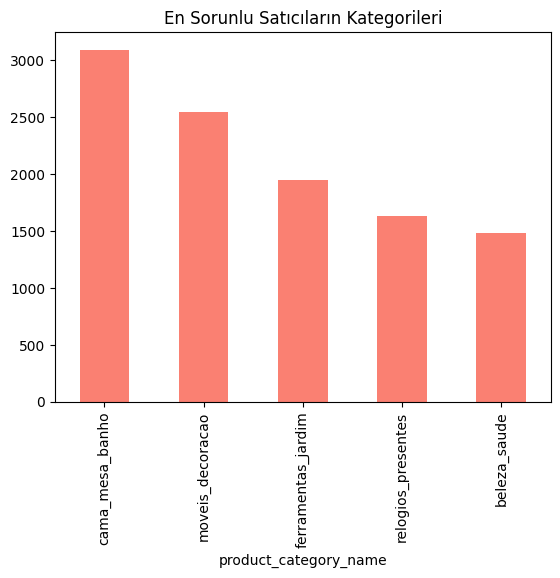

In [39]:
import pandas as pd
from olist.data import Olist

# 1. Tüm veri setlerini tek bir merkezden çekiyoruz (Bu yöntem hata payını sıfırlar)
olist_data = Olist().get_data()

# 2. İhtiyacımız olan tabloları değişkenlere atayalım
df_products = olist_data['products']
df_order_items = olist_data['order_items']

# 3. Kötü satıcılarımızı (az önce bulmuştuk) alalım
# Not: worst_sellers değişkeninin hala hafızada olduğunu varsayıyoruz
worst_seller_ids = worst_sellers["seller_id"].tolist()

# 4. EN KRİTİK ADIM: Kötü satıcıları, sattıkları ürünler ve kategorileriyle birleştirelim
# Önce sipariş kalemlerini (order_items) ürünlerle (products) birleştiriyoruz
merged_data = df_order_items.merge(df_products, on="product_id")

# Şimdi sadece bizim "Kötü 10" satıcımızın olduğu satırları filtreliyoruz
worst_sellers_final_table = merged_data[merged_data["seller_id"].isin(worst_seller_ids)]

# 5. SONUÇ: Hangi kategoriler başı çekiyor?
print("🚨 CEO RAPORU: En Kötü Satıcıların Yoğunlaştığı Kategoriler:")
results = worst_sellers_final_table["product_category_name"].value_counts()
print(results)

# Görsel olarak ilk 5'i görelim
results.head(5).plot(kind='bar', color='salmon', title='En Sorunlu Satıcıların Kategorileri')

In [40]:
# 1. Hocanın beklediği 'data' değişkenini (Olist sözlüğü) hazırlayalım
from olist.data import Olist
data = Olist().get_data()

# 2. Hocanın beklediği 'products' değişkenini hazırlayalım
# Sütun ismini 'product_category_name'den hocanın istediği 'category'ye çeviriyoruz
products = data['products'][['product_id', 'product_category_name']].copy()
products.columns = ['product_id', 'category']

# 3. Hocanın bir sonraki hücresindeki 'order_items' değişkeni zaten data["order_items"] içinde var.
# Şimdi hocanın o meşhur birleştirme (merge) kodunu manuel tetikleyelim
sellers_product_category = data["order_items"].merge(products, on="product_id", how="left")[["seller_id", "category"]]

print("✅ Köprü kuruldu! Değişkenler hocanın beklediği formatta hazır.")
sellers_product_category.head()

✅ Köprü kuruldu! Değişkenler hocanın beklediği formatta hazır.


,seller_id,category
0,48436dade18ac8b2bce089ec2a041202,cool_stuff
1,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop
2,5b51032eddd242adc84c38acab88f23d,moveis_decoracao
3,9d7a1d34a5052409006425275ba1c2b4,perfumaria
4,df560393f3a51e74553ab94004ba5c87,ferramentas_jardim


❓ En kötü satıcılar tarafından satılan ürün türleri nelerdir? ❓

In [41]:
sellers_product_category = data["order_items"].merge(products,
                                             on = "product_id", how = "left")[["seller_id", "category"]]

sellers_product_category

,seller_id,category
0,48436dade18ac8b2bce089ec2a041202,cool_stuff
1,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop
2,5b51032eddd242adc84c38acab88f23d,moveis_decoracao
3,9d7a1d34a5052409006425275ba1c2b4,perfumaria
4,df560393f3a51e74553ab94004ba5c87,ferramentas_jardim
...,...,...
112645,b8bc237ba3788b23da09c0f1f3a3288c,utilidades_domesticas
112646,f3c38ab652836d21de61fb8314b69182,informatica_acessorios
112647,c3cfdc648177fdbbbb35635a37472c53,esporte_lazer
112648,2b3e4a2a3ea8e01938cabda2a3e5cc79,informatica_acessorios


In [42]:
sellers_product_category.groupby("seller_id").count()

,category
seller_id,
0015a82c2db000af6aaaf3ae2ecb0532,3
001cca7ae9ae17fb1caed9dfb1094831,239
001e6ad469a905060d959994f1b41e4f,1
002100f778ceb8431b7a1020ff7ab48f,55
003554e2dce176b5555353e4f3555ac8,0
...,...
ffcfefa19b08742c5d315f2791395ee5,1
ffdd9f82b9a447f6f8d4b91554cc7dd3,20
ffeee66ac5d5a62fe688b9d26f83f534,14


### (5.3) En kötü satıcılar için kategoriler ve konular

🎁 İşte bazı kullanışlı işlevler:
- Bir satıcı tarafından satılan ürün kategorilerini göstermek için `focus_seller(seller_id)`
- Bir satıcı için en sık kullanılan konuların en popüler kelimelerini göstermek için `bad_reviews_seller`

In [43]:
def focus_seller(seller_id):
    return sellers_product_category[sellers_product_category.seller_id == seller_id].value_counts()

In [44]:
bad_reviews_sellers = worst_products_reviews.merge(data["order_items"])
bad_reviews_sellers.head(3)

,review_id,length_review,review_score,order_id,product_category_name,full_review,cleaned_review,dominant_topic,most_important_topic,most_important_words,full_review_cleaned,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,c422274e50e900b46fee429016c5458d,7,3,950bb159eea525ff8947b92c93b02f8e,moveis_escritorio,Gostei,gostei,1,1,qualidade estou bom comprei aguardando gostei ...,gostei,1,86f2416d4670e4ea3ca5494d043d9f24,7c67e1448b00f6e969d365cea6b010ab,2017-09-22 04:55:08,159.94,25.63
1,1f836d160f50247a394034abd93b7c24,22,3,7951fe56cf685dca47524b1986bf56b6,casa_construcao,Esperando o instalador,esperando instalador,1,1,qualidade estou bom comprei aguardando gostei ...,esperando instalador,1,5926c58c462b5d1f932ef3f0a9e37d41,c64a2aec32cc408a8a4c6d7c46017f91,2017-12-27 23:14:26,386.75,63.17
2,8f16e30ff188fe57a427fee7afb60c90,46,1,f4836c9fdf304c98f625b549ea6bbc39,moveis_escritorio,O tampo da mesa chegou todo amassado e batido.,tampo mesa chegou todo amassado batido,2,2,entregue prazo chegou produtos loja recomendo ...,tampo mesa chegou todo amassado batido,1,4c1bbc12438daec98a77243c2bf7a3ba,7c67e1448b00f6e969d365cea6b010ab,2017-05-26 02:50:49,146.99,32.06


In [45]:
def bad_reviews_seller(bad_reviews_sellers, seller_id):
    mask = (bad_reviews_sellers.seller_id == seller_id)
    temp = bad_reviews_sellers[mask]
    if len(temp) > 0: # satıcı kötü yorumlar veri çerçevesinde görünüyorsa
        most_frequent_topic_seller = list(temp.most_important_topic.value_counts().head(1).index)[0]
        return topic_word_mixture[most_frequent_topic_seller]

❓Bu en az satan ürünlerin her biri için en sık kullanılan ürün kategorilerini ve kelimeleri gösterin ❓

In [46]:
for worst_seller in worst_sellers["seller_id"]:
    print("-"*50)
    print(f"Focusing on the seller #{worst_seller}...")
    print(focus_seller(worst_seller))
    print(bad_reviews_seller(bad_reviews_sellers, worst_seller))


--------------------------------------------------
Focusing on the seller #955fee9216a65b617aa5c0531780ce60...
seller_id                         category                                      
955fee9216a65b617aa5c0531780ce60  moveis_decoracao                                  535
                                  utilidades_domesticas                             242
                                  esporte_lazer                                     136
                                  beleza_saude                                      119
                                  cool_stuff                                        115
                                  ferramentas_jardim                                 65
                                  construcao_ferramentas_iluminacao                  57
                                  papelaria                                          49
                                  industria_comercio_e_negocios                      33
                

🏁 Tebrikler. NLP'nin bazı temellerini (Ön İşleme + Vektörleştirme + NB/LDA) öğrendiniz ve bu yeni “uzmanlığı” Karar Bilimi ile birleştirdik.

💾 `git add / commit / push` yapmayı unutmayın.